In [1]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle


import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
from STX3KO_analyses import utilities_ES as u_es
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
with open('/home/mplitt/shuffle_pkls/dense_place_field_spatial_shuffle_spks_th.pkl','rb') as file:
    shuff_results = pickle.load(file)

In [7]:
mouse = 'mCherry6'
day = 0
ttype = 'fam'

In [8]:
# from STX3KO_analyses import run_sig_fields_spatial_perm as perms
sess = u.load_single_day(mouse, day)
field_info = shuff_results[mouse][day][ttype]
# thresh_mat =  shuff_results[ko_mice[1]][0]['nov']

trial_mat = sess.trial_matrices['spks_th'][sess.trial_info['LR']!=sess.novel_arm,:,:]
# field_mask = np.nanmean(trial_mat,axis=0)>thresh_mat

# field_mask.shape
# rising_edges, falling_edges, field_widths, num_fields = perms.get_field_stats(field_mask)
# field_info = {'rising_edges': rising_edges,
#               'falling_edges': falling_edges,
#               'field_widths': field_widths,
#               'num_fields': num_fields}

{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 0}


In [9]:
field_info

{'field_mask': array([[0, 1, 0, ..., 0, 0, 0],
        [0, 1, 0, ..., 0, 0, 0],
        [0, 1, 0, ..., 0, 0, 0],
        ...,
        [1, 0, 0, ..., 0, 0, 0],
        [1, 0, 0, ..., 0, 0, 0],
        [1, 0, 0, ..., 0, 0, 0]], shape=(30, 1030)),
 'rising_edges': array([[   0,    9],
        [   0,   18],
        [   1,    0],
        ...,
        [1025,    2],
        [1025,   27],
        [1027,   20]], shape=(1039, 2)),
 'falling_edges': array([[   0,   10],
        [   0,   30],
        [   1,   15],
        ...,
        [1025,    9],
        [1025,   30],
        [1027,   26]], shape=(1039, 2)),
 'field_widths': array([ 1, 12, 15, ...,  7,  3,  6], shape=(1039,))}

/tmp/ipykernel_49510/2461172193.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


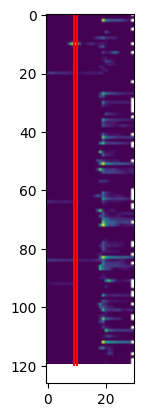

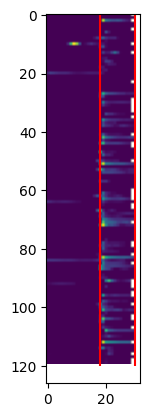

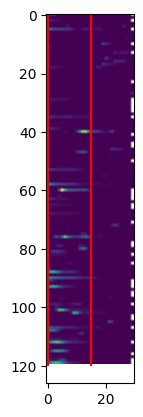

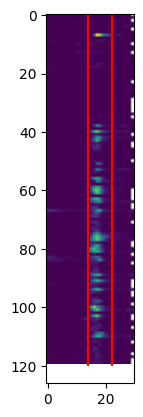

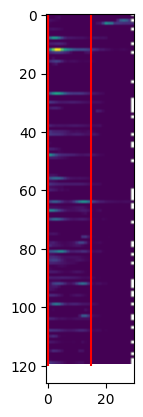

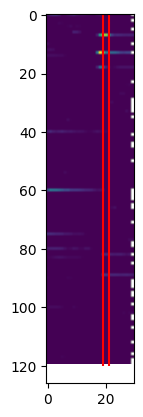

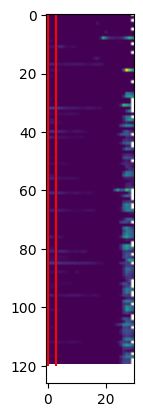

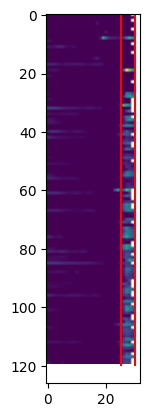

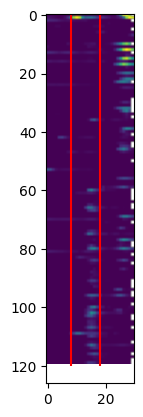

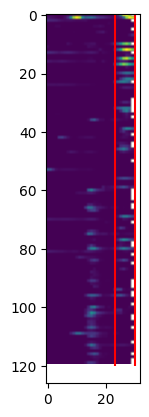

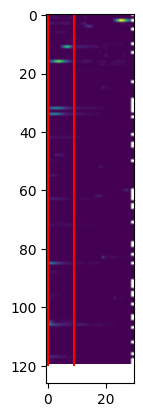

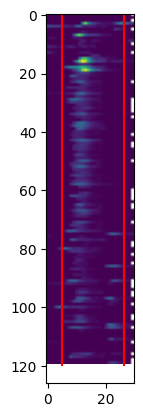

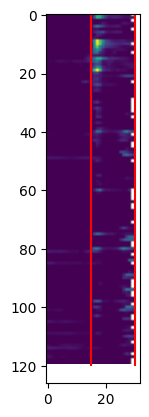

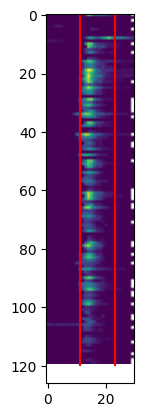

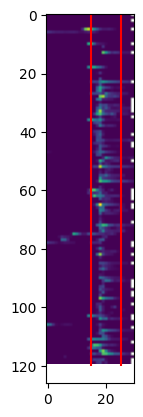

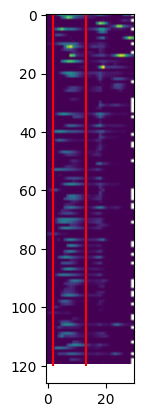

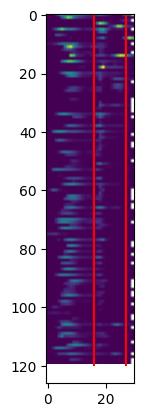

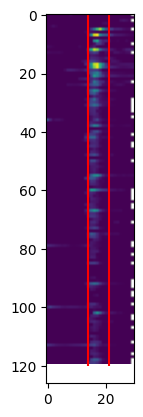

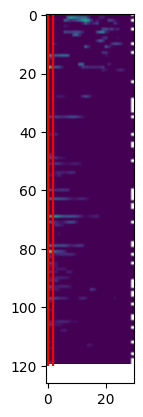

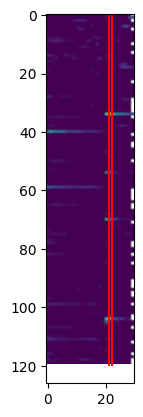

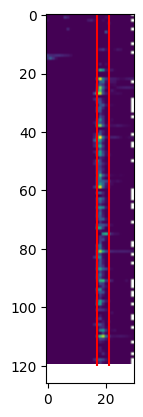

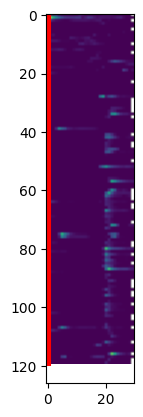

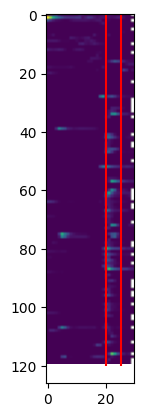

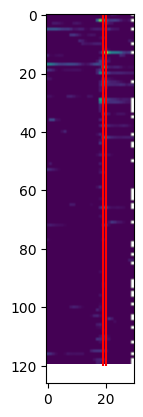

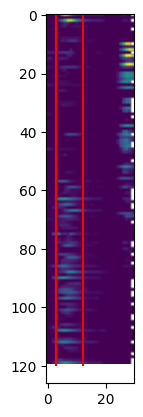

In [10]:
for i, (rising_edge, falling_edge) in enumerate(zip(field_info['rising_edges'], field_info['falling_edges'])):
    if i<25:
        fig, ax = plt.subplots()
        ax.imshow(trial_mat[:,:, rising_edge[0]])
        ax.vlines([rising_edge[1],falling_edge[1]],0,trial_mat.shape[0], color='red')